# F3NinaL — Caracterização das quatro fases: La Niña

**Projeto:** NINO-BRASIL — Oceanografia Física — UFPE  
**Código canônico:** `F3NinaL`  
**Objeto de estudo:** ciclo de vida da La Niña no Pacífico tropical  
**Família de hipótese:** `HIP0`

## 1. Contexto e delimitação científica

Este notebook fecha a caracterização do La Niña reunindo duração, nível físico, variabilidade e incerteza das quatro fases. Ele não mistura o sinal oposto nem converte a descrição retrospectiva em previsão.

## 2. Pergunta científica

Qual é a assinatura final de gênese, crescimento, pico e decaimento?

## 3. Hipótese específica

O La Niña possui assinatura multivariada e duração características em gênese, crescimento, faixa de pico e decaimento, mas com dispersão relevante entre eventos que deve acompanhar qualquer valor médio.

A hipótese poderá ser sustentada, parcialmente sustentada ou rejeitada; a execução do notebook não antecipa o resultado.

## 4. Motivação para o teste e unidade de análise

A síntese utiliza somente tabelas do escopo isolado, resume eventos com peso igual e apresenta intervalos e dispersão entre eventos. Resultados de Friedman, lags e PCA são contextualizados sem serem fundidos em um único escore arbitrário.

## 5. Metodologia

Síntese de duração, nível físico, variabilidade e incerteza entre eventos do sinal isolado.

## 6. Resultados esperados e contrato de saída

Resultados esperados significam produtos necessários para responder à pergunta, não valores ou significâncias presumidos:

- painel final das quatro fases do sinal isolado.
- duração e incerteza entre eventos por fase.
- quadro das variáveis características, discriminantes e limitações.

- figuras públicas iniciadas por `FigF3NinaL`;
- tabelas públicas iniciadas por `TabF3NinaL`;
- primeiro par reservado: `FigF3NinaL1` ↔ `TabF3NinaL1`;
- toda interpretação deve apontar para tabela, run_id, unidade, amostra e limitações.

## 7. Fundamentação científica mínima

1. Bjerknes, J. (1969). Atmospheric Teleconnections from the Equatorial Pacific. Monthly Weather Review, 97, 163–172.
2. Jin, F.-F. (1997). An Equatorial Ocean Recharge Paradigm for ENSO. Journal of the Atmospheric Sciences, 54, 811–829.

## Premissas de validade e limites de interpretação

- Toda conclusão deve nascer de uma tabela `Tab...` persistida antes da figura correspondente.
- A execução é determinística e usa somente entradas declaradas no inventário mostrado abaixo.
- Notebook executado não implica hipótese confirmada; gates científicos são exibidos como resultados.
- El Niño e La Niña são analisados isoladamente; nenhum composto mistura os dois sinais.
- Evento é a unidade independente; semanas descrevem a trajetória interna do evento.

In [1]:
from pathlib import Path
import os
import sys
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').exists())
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
NOTEBOOK_CODE = 'F3NinaL'
MODE = os.environ.get('NINO26_NOTEBOOK_MODE', 'official')
RUN_PIPELINE = os.environ.get('NINO26_RUN_PIPELINE', '0') == '1'
if RUN_PIPELINE:
    raise RuntimeError('O núcleo numérico deve ser executado pelo runner da fase, antes do notebook.')
from nino_brasil.notebook_workflows import NotebookWorkflow
workflow = NotebookWorkflow(ROOT, NOTEBOOK_CODE, mode=MODE)
workflow.describe()

{
  "notebook_code": "F3NinaL",
  "phase": 3,
  "enso_type": "la_nina",
  "mode": "official",
  "execution_policy": "numeric-core-first-viewer-publisher"
}


{'notebook_code': 'F3NinaL',
 'phase': 3,
 'enso_type': 'la_nina',
 'mode': 'official',
 'execution_policy': 'numeric-core-first-viewer-publisher'}

## Dados

In [2]:
input_inventory = workflow.input_inventory()
display(input_inventory)
workflow.require_inputs()

,role,path,required,exists,bytes
0,duração das fases,data\processed\parquet\statistics\F3Nina\TabF3...,True,True,660
1,conjuntos de variáveis por fase,data\processed\parquet\statistics\F3Nina\TabF3...,True,True,41577


## Resultados

In [3]:
result = workflow.run()
display(result.artifacts)
display(result.summary)

,notebook_code,ordinal,namespace,figure_code,table_code,figure_path,table_path,manifest_path,figure_sha256,table_sha256,run_id
0,F3NinaL,1,fase3_nina,FigF3NinaL1_duracao_fases,TabF3NinaL1_duracao_fases,C:\DEV\NINO26\data\processed\figures\fase3_nin...,C:\DEV\NINO26\data\processed\numeric-tables\fa...,C:\DEV\NINO26\data\processed\numeric-tables\fa...,501843e859380e125d5ed3f88759a2e881ccd3ea19dc40...,c03f5883cc4190b35e5148ea48d298d184a89d991c405a...,20260714T202702Z_5538a635
1,F3NinaL,2,fase3_nina,FigF3NinaL2_conjuntos_variaveis_fase,TabF3NinaL2_conjuntos_variaveis_fase,C:\DEV\NINO26\data\processed\figures\fase3_nin...,C:\DEV\NINO26\data\processed\numeric-tables\fa...,C:\DEV\NINO26\data\processed\numeric-tables\fa...,fbae668040dd03d5e1a0a5c6bf1fec28ceaeecd436ca16...,9240f773ba106c4cc98d3a7f366f8fbd3f56527c67f20f...,20260714T202702Z_5538a635


,tipo,fase,variavel,media_z_entre_eventos,desvio_z_entre_eventos,n_eventos_independentes,familia,e_alvo_termico,sensibilidade_fase,kendall_w_entre_fases,significativo_friedman_fdr,score_descritor,rank_na_fase,integra_conjunto_descritor,justificativa
0,la_nina,crescimento,nino34_ssta,-0.928987,0.286429,11,alvo_termico_nino34,True,3.243340,0.900826,True,3.078314,1.0,False,score = sensibilidade entre eventos vezes raiz...
1,la_nina,crescimento,d20_m,-1.176184,0.702185,11,oceano_subsuperficie,False,1.675034,0.282645,True,0.890521,17.0,False,score = sensibilidade entre eventos vezes raiz...
2,la_nina,crescimento,tilt_m,-0.752835,0.269406,11,oceano_subsuperficie,False,2.794431,0.715702,True,2.364066,2.0,True,score = sensibilidade entre eventos vezes raiz...
3,la_nina,crescimento,tilt_slope,-0.513304,0.288322,11,oceano_subsuperficie,False,1.780315,0.821488,True,1.613605,9.0,False,score = sensibilidade entre eventos vezes raiz...
4,la_nina,crescimento,ohc_0_100,-1.145807,0.389686,11,oceano_subsuperficie,False,2.940335,0.563636,True,2.207477,3.0,True,score = sensibilidade entre eventos vezes raiz...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,la_nina,pico,u850_anom,-0.853517,0.399495,11,atmosfera,False,2.136490,0.583471,True,1.631964,9.0,False,score = sensibilidade entre eventos vezes raiz...
120,la_nina,pico,u200_anom,0.777804,0.597334,11,atmosfera,False,1.302127,0.490909,True,0.912334,18.0,False,score = sensibilidade entre eventos vezes raiz...
121,la_nina,pico,omega850_anom,0.820165,0.340922,11,atmosfera,False,2.405725,0.305785,True,1.330314,11.0,False,score = sensibilidade entre eventos vezes raiz...
122,la_nina,pico,omega500_anom,0.446710,0.233601,11,atmosfera,False,1.912276,0.338843,True,1.113140,15.0,False,score = sensibilidade entre eventos vezes raiz...


## Figuras para verificação rápida

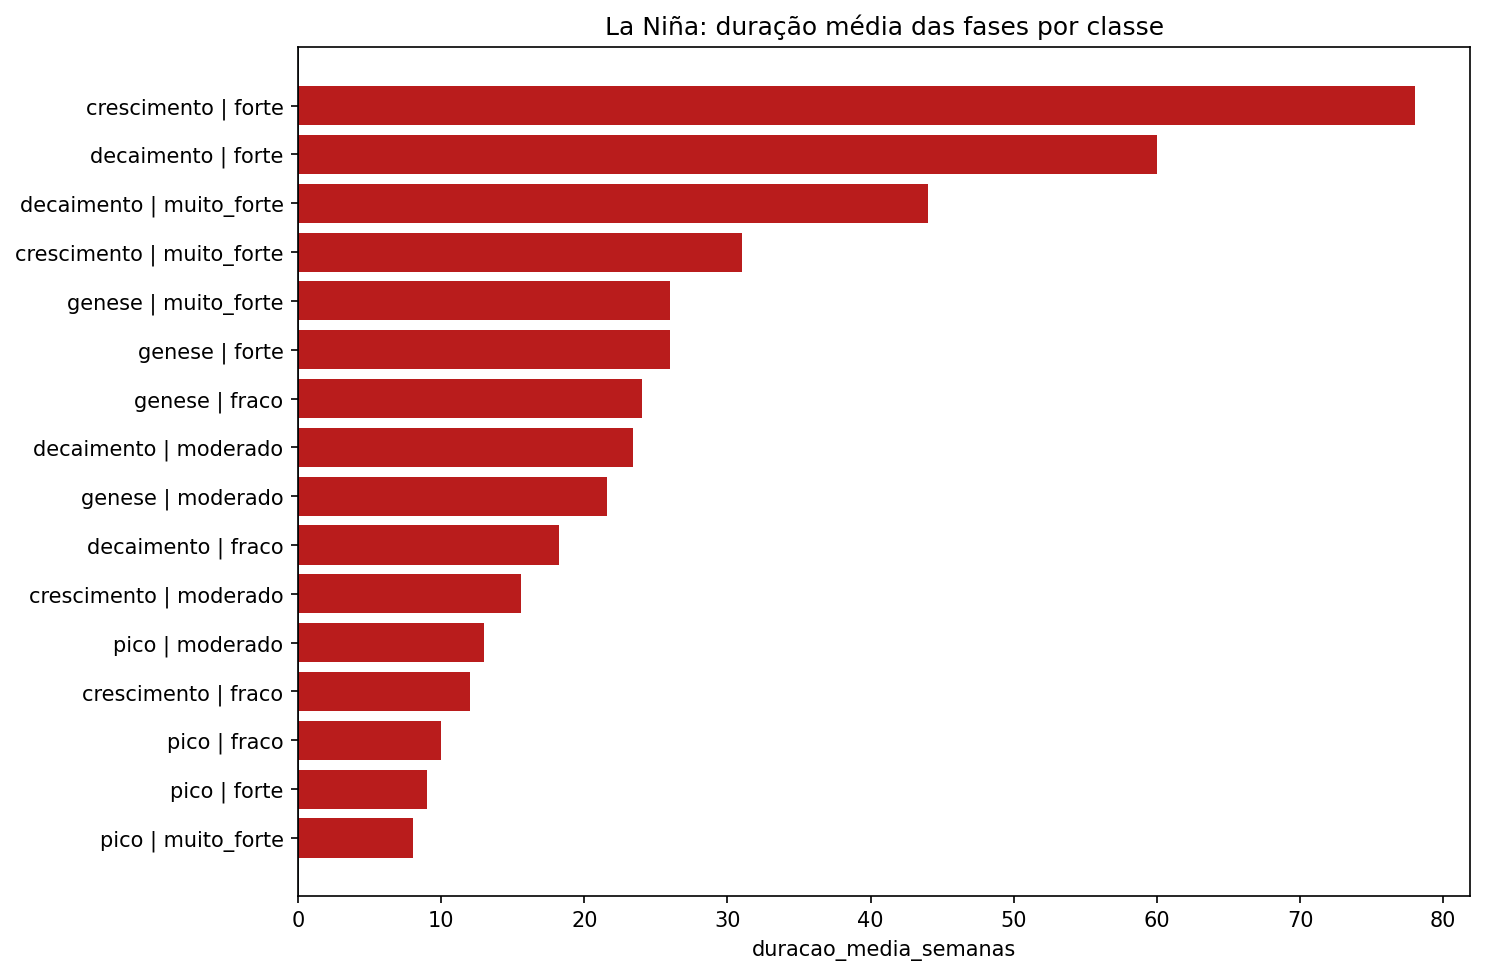

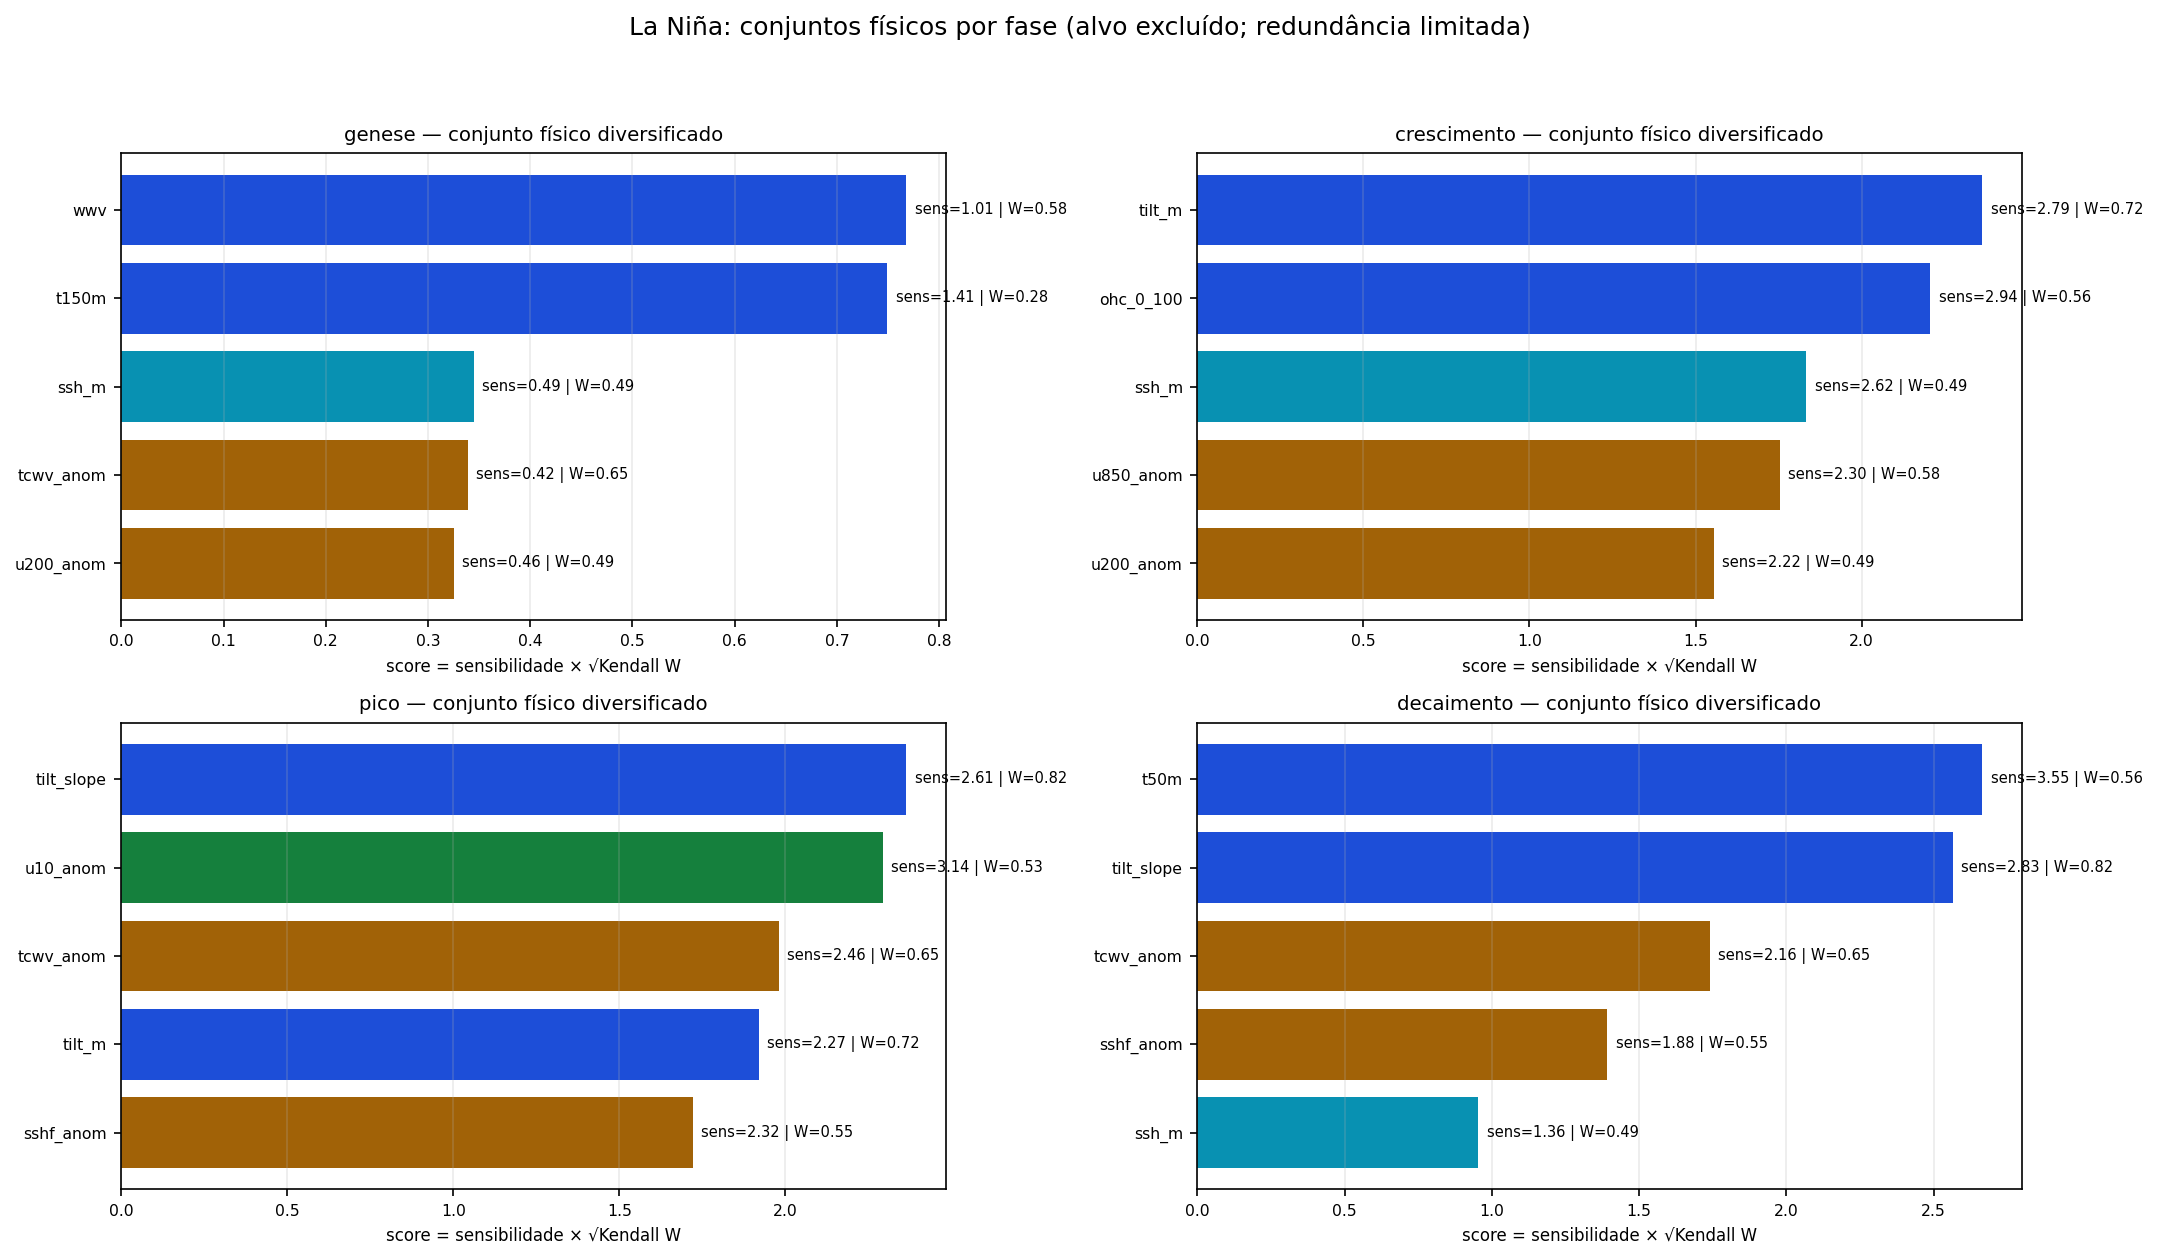

In [4]:
from IPython.display import Image, display

for artifact in result.artifacts.itertuples(index=False):
    display(Image(filename=str(artifact.figure_path)))

## Conclusões

In [5]:
for item in result.takeaways:
    print(f'- {item}')
print('\nLimitações:')
for item in result.limitations:
    print(f'- {item}')

- Conjunto físico diversificado por fase (alvo térmico excluído da seleção): crescimento: atmosfera, oceano_subsuperficie, oceano_superficie; decaimento: atmosfera, oceano_subsuperficie, oceano_superficie; genese: atmosfera, oceano_subsuperficie, oceano_superficie; pico: acoplamento_vento_oceano, atmosfera, oceano_subsuperficie.
- A duração média por fase e classe usa somente os eventos elegíveis do sinal isolado.

Limitações:
- As figuras resumem tabelas auditadas; consulte tabela, manifesto e unidade antes de interpretar valores individuais.
- Leituras de propagação e influência são diagnósticas por evento; não há detector formal de onda nem atribuição causal.
- Somente eventos elegíveis do sinal isolado entram nos painéis; o número de eventos independentes acompanha cada tabela.
